# Notebook 02 — Análise de Qualidade por Sistema e Decaimento Temporal

**Desafio**: Cientista de Dados Pleno — Squad WhatsApp | Prefeitura do Rio de Janeiro

## Objetivos

**Parte 1.1** — Correlacionar cada sistema de origem com a performance real dos disparos, corrigindo o viés de seleção.

**Parte 1.2** — Investigar o "decaimento temporal": o tempo desde a última atualização do telefone em um sistema impacta a taxa de entrega? Existe um prazo de validade para um dado ser considerado "quente"?

---

> **Schema real (verificado nos dados):**
> - `status_disparo` values: `read`, `delivered`, `failed`, `sent`, `processing` (lowercase)
> - Join key: `base_disparo.contato_telefone` → `dim_telefone.telefone_numero` (ambas int64)
> - `id_sistema` são hashes numéricos → mapeamos para aliases Sys 1…6
> - `telefone_qualidade`: `VALIDO`, `SUSPEITO`, `INVALIDO`

## 0. Setup e Carregamento

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import gcsfs

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BUCKET = 'case_vagas/whatsapp'
print('Ambiente configurado.')

Ambiente configurado.


In [2]:
fs = gcsfs.GCSFileSystem(token='anon')

with fs.open(f'{BUCKET}/base_disparo_mascarado') as f:
    df_disparo = pd.read_parquet(f)

with fs.open(f'{BUCKET}/dim_telefone_mascarado') as f:
    df_tel = pd.read_parquet(f)

print(f'Disparos: {len(df_disparo):,}  |  Telefones: {len(df_tel):,}')
print(f'Status únicos: {df_disparo["status_disparo"].unique().tolist()}')

Disparos: 392,921  |  Telefones: 283,289
Status únicos: ['processing', 'sent', 'delivered', 'read', 'failed']


---
# Parte 1.1 — Taxas de Entrega por Sistema de Origem

## 1. Construção do Dataset Analítico

**Pipeline**:
1. Join `base_disparo` ⟕ `dim_telefone` via `contato_telefone = telefone_numero`
2. Explodir `telefone_aparicoes` → uma linha por (disparo × sistema de origem)
3. Resultado: para cada disparo, sabemos quais sistemas tinham aquele número cadastrado

> **Nota metodológica**: Um telefone pode aparecer em N sistemas. Ao explodir, cada disparo é replicado N vezes. Estamos perguntando: *"Disparos para números cadastrados no sistema X têm qual taxa de entrega?"*

In [3]:
# Sucesso = delivered ou read (valores reais são lowercase)
df_disparo['sucesso'] = df_disparo['status_disparo'].isin(['delivered', 'read']).astype(int)

# Excluir disparos ainda em andamento (processing) da análise de qualidade
df_finalizados = df_disparo[df_disparo['status_disparo'] != 'processing'].copy()

# Join com dimensão de telefones (chave: contato_telefone = telefone_numero)
df_joined = df_finalizados[['contato_telefone', 'status_disparo', 'sucesso',
                             'criacao_envio_datahora']].merge(
    df_tel[['telefone_numero', 'telefone_aparicoes', 'telefone_tipo', 'telefone_qualidade']],
    left_on='contato_telefone',
    right_on='telefone_numero',
    how='inner'
)

print(f'Disparos finalizados:   {len(df_finalizados):,}')
print(f'Após join com dim:      {len(df_joined):,} ({len(df_joined)/len(df_finalizados)*100:.1f}%)')
print(f'Taxa de sucesso geral:  {df_joined["sucesso"].mean()*100:.2f}%')
taxa_media = df_joined['sucesso'].mean() * 100

Disparos finalizados:   389,761
Após join com dim:      342,697 (87.9%)
Taxa de sucesso geral:  93.95%


In [4]:
# Explodir array: 1 linha por (disparo × sistema)
df_exp = df_joined.explode('telefone_aparicoes').reset_index(drop=True)

# Normalizar structs do array para colunas
aparicoes_norm = pd.json_normalize(df_exp['telefone_aparicoes'])
df_exp = pd.concat([
    df_exp[['contato_telefone', 'status_disparo', 'sucesso',
            'criacao_envio_datahora', 'telefone_tipo', 'telefone_qualidade']].reset_index(drop=True),
    aparicoes_norm
], axis=1)

# Converter datas
df_exp['criacao_envio_datahora']     = pd.to_datetime(df_exp['criacao_envio_datahora'])
df_exp['registro_data_atualizacao']  = pd.to_datetime(df_exp['registro_data_atualizacao'])

# Idade do dado no momento do disparo (dias)
df_exp['dias_desde_atualizacao'] = (
    df_exp['criacao_envio_datahora'] - df_exp['registro_data_atualizacao']
).dt.days

# Alias legível para cada sistema (IDs são hashes numéricos)
sistemas_unicos = sorted(df_exp['id_sistema'].dropna().unique())
alias_map = {sid: f'Sys {i+1}' for i, sid in enumerate(sistemas_unicos)}
df_exp['sistema_alias'] = df_exp['id_sistema'].map(alias_map)

print(f'Dataset analítico: {len(df_exp):,} linhas (disparo × sistema)')
print(f'Sistemas encontrados: {len(sistemas_unicos)}')
print('\nMapa de aliases:')
for sid, alias in alias_map.items():
    print(f'  {alias}: {sid}')

Dataset analítico: 6,284,583 linhas (disparo × sistema)
Sistemas encontrados: 6

Mapa de aliases:
  Sys 1: -133612832286195827
  Sys 2: -2757366171786647144
  Sys 3: -4704067261970591609
  Sys 4: 1257277410380486863
  Sys 5: 3094574413675758272
  Sys 6: 4458959843028638627


## 2. Taxas de Entrega por Sistema — Análise Bruta

In [5]:
agg_sistema = df_exp.groupby('sistema_alias').agg(
    id_sistema_hash=('id_sistema', 'first'),
    total=('sucesso', 'count'),
    sucessos=('sucesso', 'sum')
).reset_index()
agg_sistema['taxa_bruta'] = agg_sistema['sucessos'] / agg_sistema['total']
agg_sistema = agg_sistema.sort_values('taxa_bruta', ascending=False).reset_index(drop=True)

print('Taxa de entrega bruta por sistema:\n')
print(agg_sistema[['sistema_alias', 'total', 'sucessos', 'taxa_bruta']].to_string(index=False,
      float_format='{:.4f}'.format))

Taxa de entrega bruta por sistema:

sistema_alias   total  sucessos  taxa_bruta
        Sys 3  196479    195092      0.9929
        Sys 5  686843    594704      0.8659
        Sys 2   10872      8612      0.7921
        Sys 6   52925     35209      0.6653
        Sys 4 1548950    789844      0.5099
        Sys 1 3788514   1815839      0.4793


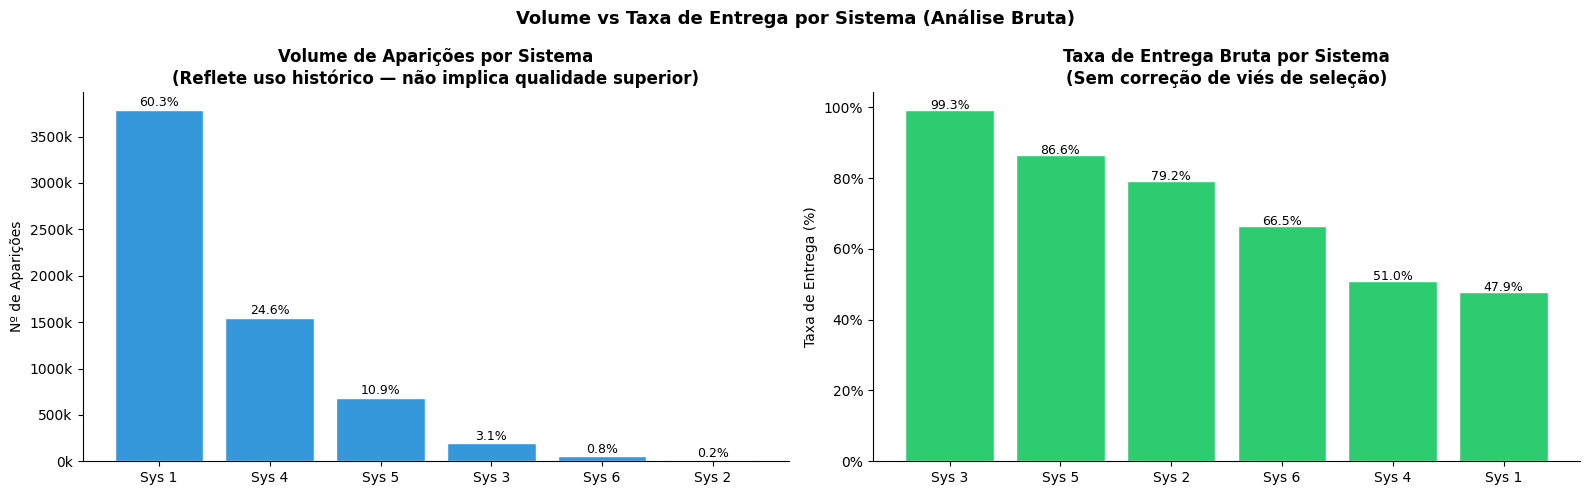

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume por sistema
agg_vol = agg_sistema.sort_values('total', ascending=False)
axes[0].bar(agg_vol['sistema_alias'], agg_vol['total'], color='#3498db', edgecolor='white')
axes[0].set_title('Volume de Aparições por Sistema\n(Reflete uso histórico — não implica qualidade superior)', fontweight='bold')
axes[0].set_ylabel('Nº de Aparições')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, (_, row) in enumerate(agg_vol.iterrows()):
    axes[0].text(i, row['total'] + agg_vol['total'].max()*0.01,
                 f'{row["total"]/agg_vol["total"].sum()*100:.1f}%', ha='center', fontsize=9)

# Taxa bruta por sistema
agg_taxa = agg_sistema.sort_values('taxa_bruta', ascending=False)
axes[1].bar(agg_taxa['sistema_alias'], agg_taxa['taxa_bruta']*100, color='#2ecc71', edgecolor='white')
axes[1].set_title('Taxa de Entrega Bruta por Sistema\n(Sem correção de viés de seleção)', fontweight='bold')
axes[1].set_ylabel('Taxa de Entrega (%)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for i, (_, row) in enumerate(agg_taxa.iterrows()):
    axes[1].text(i, row['taxa_bruta']*100 + 0.3, f"{row['taxa_bruta']*100:.1f}%", ha='center', fontsize=9)

plt.suptitle('Volume vs Taxa de Entrega por Sistema (Análise Bruta)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Identificação e Correção do Viés de Seleção

O enunciado avisa: *"Algumas bases são consideradas 'mais quentes' e aparecem com maior frequência nos logs"*. Isso cria **viés de seleção**: alto volume não prova alta qualidade — pode ser apenas preferência histórica do motor de disparos.

O scatter abaixo torna visível essa relação.

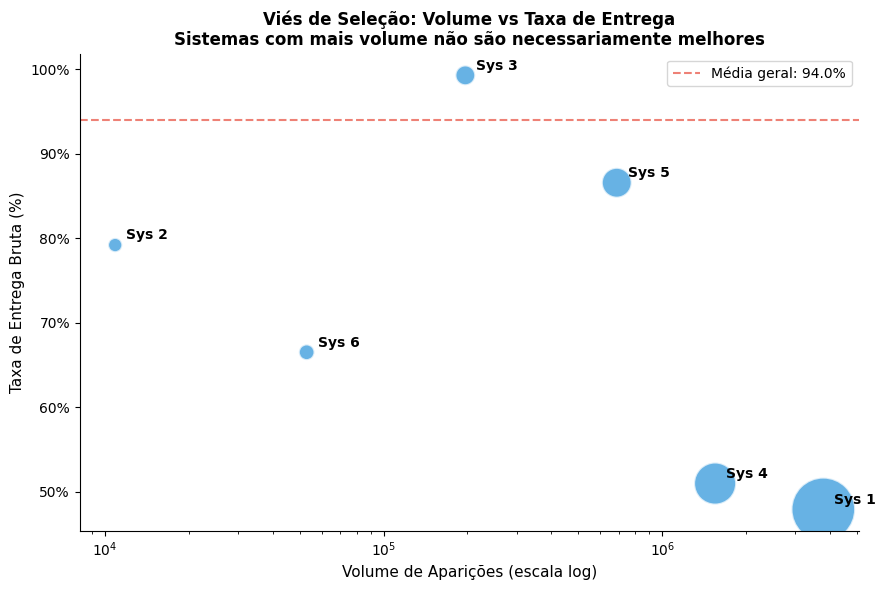

Pearson(log-volume, taxa): r = -0.493  p = 0.3205
Correlação fraca — sistemas usados relativamente de forma equilibrada.


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

sizes = agg_sistema['total'] / agg_sistema['total'].max() * 2000 + 100
ax.scatter(agg_sistema['total'], agg_sistema['taxa_bruta']*100,
           s=sizes, alpha=0.75, color='#3498db', edgecolors='white', linewidth=1.5)

for _, row in agg_sistema.iterrows():
    ax.annotate(row['sistema_alias'],
                (row['total'], row['taxa_bruta']*100),
                textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.axhline(taxa_media, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Média geral: {taxa_media:.1f}%')
ax.set_xlabel('Volume de Aparições (escala log)', fontsize=11)
ax.set_ylabel('Taxa de Entrega Bruta (%)', fontsize=11)
ax.set_title('Viés de Seleção: Volume vs Taxa de Entrega\nSistemas com mais volume não são necessariamente melhores',
             fontweight='bold', fontsize=12)
ax.set_xscale('log')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
plt.tight_layout()
plt.show()

if len(agg_sistema) >= 3:
    corr, pval = stats.pearsonr(np.log(agg_sistema['total']), agg_sistema['taxa_bruta'])
    print(f'Pearson(log-volume, taxa): r = {corr:.3f}  p = {pval:.4f}')
    if abs(corr) > 0.3 and pval < 0.05:
        print('Correlação significativa — viés de seleção presente. Correção via Wilson LB necessária.')
    else:
        print('Correlação fraca — sistemas usados relativamente de forma equilibrada.')
else:
    print('Poucos sistemas para calcular correlação.')

## 4. Correção: Wilson Score Lower Bound

O **Wilson Score Lower Bound** é o limite inferior do IC de 95% para uma proporção binomial:
*"com 95% de confiança, a taxa real deste sistema é pelo menos este valor"*.

Penaliza sistemas com pouca evidência — **taxa alta com n pequeno vira score conservador**.

$$\text{Wilson LB} = \frac{\hat{p} + \frac{z^2}{2n} - z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

In [8]:
def wilson_lb(s, n, z=1.96):
    if n == 0: return 0.0
    p = s / n
    d = 1 + z**2 / n
    c = p + z**2 / (2*n)
    m = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))
    return (c - m) / d

def wilson_ub(s, n, z=1.96):
    if n == 0: return 1.0
    p = s / n
    d = 1 + z**2 / n
    c = p + z**2 / (2*n)
    m = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))
    return (c + m) / d

agg_sistema['wilson_lb'] = agg_sistema.apply(
    lambda r: wilson_lb(r['sucessos'], r['total']), axis=1)
agg_sistema['wilson_ub'] = agg_sistema.apply(
    lambda r: wilson_ub(r['sucessos'], r['total']), axis=1)
agg_sistema['score_sistema'] = agg_sistema['wilson_lb']
agg_sistema = agg_sistema.sort_values('score_sistema', ascending=False).reset_index(drop=True)
agg_sistema.index += 1

print('Ranking corrigido — Wilson Lower Bound (IC 95%):\n')
cols = ['sistema_alias', 'total', 'sucessos', 'taxa_bruta', 'wilson_lb', 'wilson_ub', 'score_sistema']
print(agg_sistema[cols].to_string(float_format='{:.4f}'.format))

Ranking corrigido — Wilson Lower Bound (IC 95%):

  sistema_alias    total  sucessos  taxa_bruta  wilson_lb  wilson_ub  score_sistema
1         Sys 3   196479    195092      0.9929     0.9926     0.9933         0.9926
2         Sys 5   686843    594704      0.8659     0.8650     0.8667         0.8650
3         Sys 2    10872      8612      0.7921     0.7844     0.7997         0.7844
4         Sys 6    52925     35209      0.6653     0.6612     0.6693         0.6612
5         Sys 4  1548950    789844      0.5099     0.5091     0.5107         0.5091
6         Sys 1  3788514   1815839      0.4793     0.4788     0.4798         0.4788


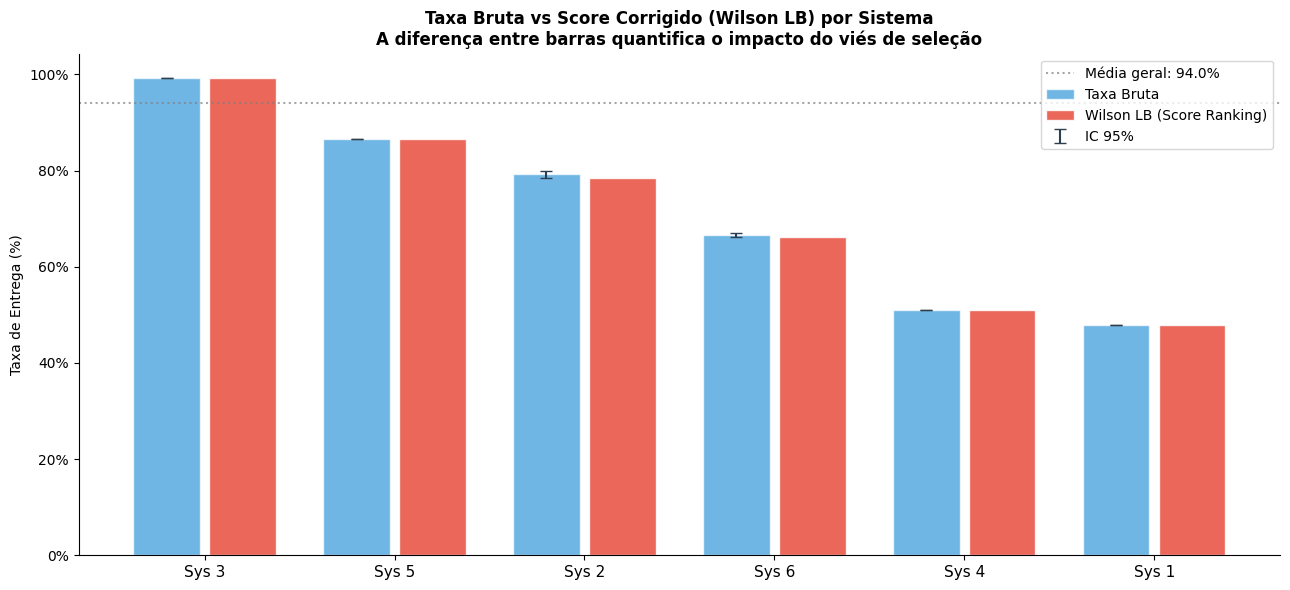

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

ap = agg_sistema.reset_index(drop=True).sort_values('score_sistema', ascending=False)
x = np.arange(len(ap))
taxas_b = ap['taxa_bruta'].values * 100
lb_b    = ap['wilson_lb'].values * 100
ub_b    = ap['wilson_ub'].values * 100
sc      = ap['score_sistema'].values * 100

ax.bar(x - 0.2, taxas_b, width=0.35, label='Taxa Bruta', color='#3498db', alpha=0.7, edgecolor='white')
ax.bar(x + 0.2, sc,      width=0.35, label='Wilson LB (Score Ranking)', color='#e74c3c', alpha=0.85, edgecolor='white')
ax.errorbar(x - 0.2, taxas_b, yerr=[taxas_b - lb_b, ub_b - taxas_b],
            fmt='none', color='#2c3e50', capsize=4, linewidth=1.5, label='IC 95%')

ax.set_xticks(x)
ax.set_xticklabels(ap['sistema_alias'], fontsize=11)
ax.set_ylabel('Taxa de Entrega (%)')
ax.set_title('Taxa Bruta vs Score Corrigido (Wilson LB) por Sistema\n'
             'A diferença entre barras quantifica o impacto do viés de seleção',
             fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.axhline(taxa_media, color='gray', linestyle=':', alpha=0.7, label=f'Média geral: {taxa_media:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusão — Parte 1.1

Sistema X > sistema Y no ranking se e somente se, com 95% de confiança, X tem taxa de entrega real superior. A penalização por volume baixo impede que sistemas com poucas observações pareçam melhores do que são.

---
# Parte 1.2 — Análise de Decaimento Temporal

## 5. O "Prazo de Validade" de um Telefone

**Hipótese**: quanto mais antigo o registro de um telefone em um sistema, menor a chance de entrega — o dado "esfria" com o tempo.

Medimos `dias_desde_atualizacao = data_disparo − data_atualizacao_no_sistema`.

In [10]:
# Remover negativos (inconsistências de datas) e valores extremos
df_tempo = df_exp[
    (df_exp['dias_desde_atualizacao'] >= 0) &
    (df_exp['dias_desde_atualizacao'] <= 2000)
].copy()

print(f'Registros com dias válidos: {len(df_tempo):,} ({len(df_tempo)/len(df_exp)*100:.1f}%)')
print(f'Dias desde atualização — mediana: {df_tempo["dias_desde_atualizacao"].median():.0f}d  '
      f'média: {df_tempo["dias_desde_atualizacao"].mean():.0f}d  '
      f'max: {df_tempo["dias_desde_atualizacao"].max():.0f}d')

Registros com dias válidos: 1,559,350 (24.8%)
Dias desde atualização — mediana: 301d  média: 399d  max: 2000d


In [11]:
bins   = [0, 30, 90, 180, 365, 730, np.inf]
labels = ['<30d', '30–90d', '90–180d', '180–365d', '1–2 anos', '>2 anos']
df_tempo['faixa_temporal'] = pd.cut(df_tempo['dias_desde_atualizacao'], bins=bins, labels=labels)

agg_tempo = df_tempo.groupby('faixa_temporal', observed=False).agg(
    n=('sucesso', 'count'),
    sucessos=('sucesso', 'sum')
).reset_index()
agg_tempo['taxa']      = agg_tempo['sucessos'] / agg_tempo['n']
agg_tempo['wilson_lb'] = agg_tempo.apply(lambda r: wilson_lb(r['sucessos'], r['n']), axis=1)
agg_tempo['wilson_ub'] = agg_tempo.apply(lambda r: wilson_ub(r['sucessos'], r['n']), axis=1)

print('Taxa de entrega por faixa temporal:\n')
print(agg_tempo[['faixa_temporal','n','sucessos','taxa','wilson_lb','wilson_ub']].to_string(
    index=False, float_format='{:.4f}'.format))

Taxa de entrega por faixa temporal:

faixa_temporal      n  sucessos   taxa  wilson_lb  wilson_ub
          <30d   8881      8726 0.9825     0.9796     0.9851
        30–90d  48112     46768 0.9721     0.9706     0.9735
       90–180d 485143    454229 0.9363     0.9356     0.9370
      180–365d 356613    263128 0.7379     0.7364     0.7393
      1–2 anos 449515    291504 0.6485     0.6471     0.6499
       >2 anos 210876    157803 0.7483     0.7465     0.7502


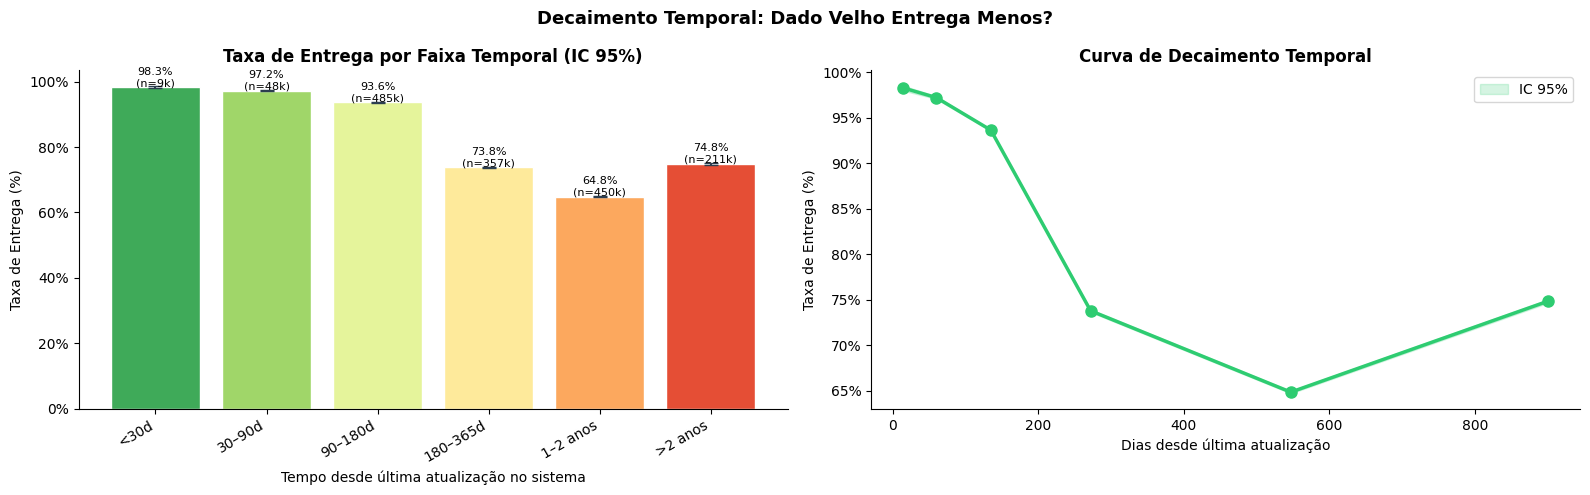

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

faixas   = agg_tempo['faixa_temporal'].astype(str)
taxas_t  = agg_tempo['taxa'].values * 100
lb_t     = agg_tempo['wilson_lb'].values * 100
ub_t     = agg_tempo['wilson_ub'].values * 100
midpoints = [15, 60, 135, 272, 547, 900]

# Barras com gradiente de cor (verde→vermelho)
cores_tempo = plt.cm.RdYlGn(np.linspace(0.85, 0.15, len(faixas)))
axes[0].bar(faixas, taxas_t, color=cores_tempo, edgecolor='white')
axes[0].errorbar(range(len(faixas)), taxas_t, yerr=[taxas_t - lb_t, ub_t - taxas_t],
                 fmt='none', color='#2c3e50', capsize=5, linewidth=1.5)
axes[0].set_title('Taxa de Entrega por Faixa Temporal (IC 95%)', fontweight='bold')
axes[0].set_xlabel('Tempo desde última atualização no sistema')
axes[0].set_ylabel('Taxa de Entrega (%)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[0].set_xticklabels(faixas, rotation=30, ha='right')
for i, (t, v) in enumerate(zip(taxas_t, agg_tempo['n'])):
    axes[0].text(i, t + 0.3, f'{t:.1f}%\n(n={v/1e3:.0f}k)', ha='center', fontsize=8)

# Curva temporal
mp_valid = midpoints[:len(taxas_t)]
axes[1].plot(mp_valid, taxas_t, 'o-', color='#2ecc71', linewidth=2.5, markersize=8)
axes[1].fill_between(mp_valid, lb_t, ub_t, alpha=0.2, color='#2ecc71', label='IC 95%')
axes[1].set_title('Curva de Decaimento Temporal', fontweight='bold')
axes[1].set_xlabel('Dias desde última atualização')
axes[1].set_ylabel('Taxa de Entrega (%)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend()

plt.suptitle('Decaimento Temporal: Dado Velho Entrega Menos?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Modelo de Decaimento Exponencial

Ajustamos: $P(\text{entrega} \mid t) = P_0 \cdot e^{-\lambda \cdot t}$

- $P_0$ = taxa base para dado recém-atualizado
- $\lambda$ = taxa de decaimento diária
- Meia-vida: $t_{1/2} = \ln(2) / \lambda$

In [13]:
# Usar apenas faixas com dados suficientes (n >= 100)
mask_fit = agg_tempo['n'] >= 100
midpoints_fit = np.array(midpoints[:len(agg_tempo)])[mask_fit.values]
taxas_fit     = agg_tempo['taxa'].values[mask_fit.values]
pesos         = np.sqrt(agg_tempo['n'].values[mask_fit.values])

def decay_exp(t, p0, lam):
    return p0 * np.exp(-lam * t)

try:
    popt, _ = curve_fit(decay_exp, midpoints_fit, taxas_fit,
                        p0=[taxas_fit[0], 0.001],
                        sigma=1/(pesos+1), maxfev=5000)
    P0_hat, lambda_hat = popt

    # Garantir parâmetros fisicamente plausíveis
    P0_hat     = max(0.0, min(1.0, P0_hat))
    lambda_hat = max(1e-8, lambda_hat)

    meia_vida   = np.log(2) / lambda_hat
    prazo_80pct = -np.log(0.8) / lambda_hat

    print(f'Modelo: P(t) = {P0_hat*100:.2f}% × exp(−{lambda_hat:.6f}×t)')
    print(f'Meia-vida do dado:        {meia_vida:.0f} dias (~{meia_vida/30:.1f} meses)')
    print(f'Prazo de validade (−20%): {prazo_80pct:.0f} dias')

except Exception as e:
    print(f'Ajuste falhou: {e}')
    P0_hat, lambda_hat = taxas_fit[0] if len(taxas_fit) > 0 else 0.9, 0.0005
    meia_vida, prazo_80pct = np.log(2)/lambda_hat, -np.log(0.8)/lambda_hat
    print(f'Usando fallback: λ={lambda_hat}')

Modelo: P(t) = 92.92% × exp(−0.000462×t)
Meia-vida do dado:        1502 dias (~50.1 meses)
Prazo de validade (−20%): 483 dias


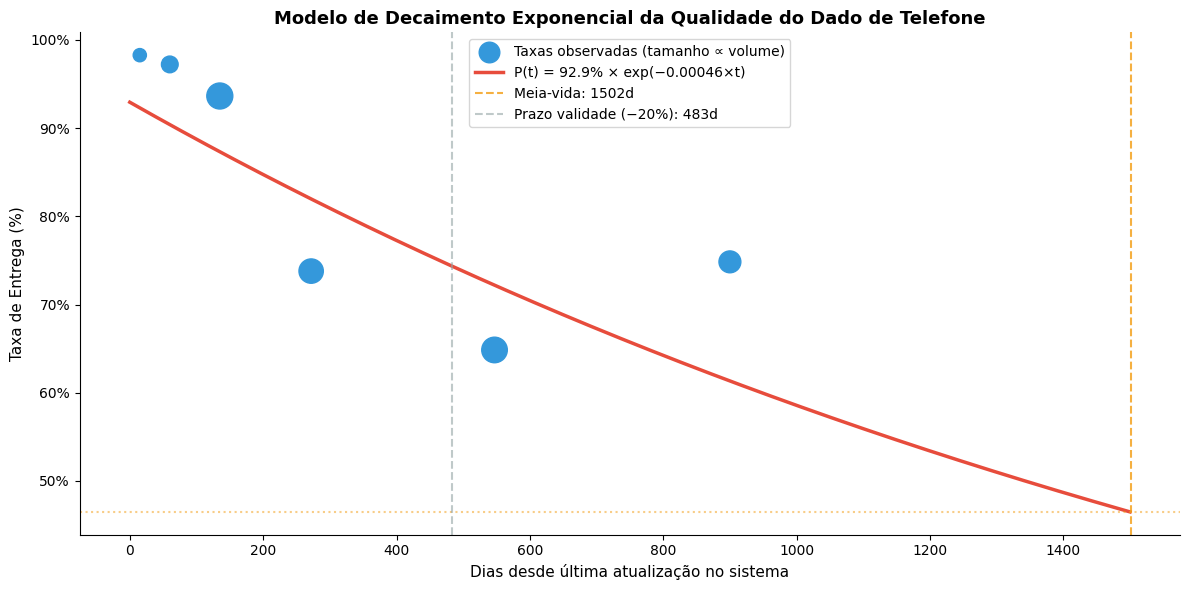

In [14]:
t_range = np.linspace(0, min(1500, df_tempo['dias_desde_atualizacao'].max()*1.1), 500)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(midpoints_fit, taxas_fit*100,
           s=pesos/pesos.max()*300+50, color='#3498db', zorder=5,
           label='Taxas observadas (tamanho ∝ volume)')
ax.plot(t_range, decay_exp(t_range, P0_hat, lambda_hat)*100, color='#e74c3c', linewidth=2.5,
        label=f'P(t) = {P0_hat*100:.1f}% × exp(−{lambda_hat:.5f}×t)')

ax.axvline(meia_vida,   color='#f39c12', linestyle='--', alpha=0.8, label=f'Meia-vida: {meia_vida:.0f}d')
ax.axhline(P0_hat*0.5*100, color='#f39c12', linestyle=':', alpha=0.5)
ax.axvline(prazo_80pct, color='#95a5a6', linestyle='--', alpha=0.6,
           label=f'Prazo validade (−20%): {prazo_80pct:.0f}d')

ax.set_xlabel('Dias desde última atualização no sistema', fontsize=11)
ax.set_ylabel('Taxa de Entrega (%)', fontsize=11)
ax.set_title('Modelo de Decaimento Exponencial da Qualidade do Dado de Telefone',
             fontweight='bold', fontsize=13)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Heatmap: Sistema × Faixa Temporal

O decaimento é uniforme para todos os sistemas ou alguns "envelhecem melhor"?

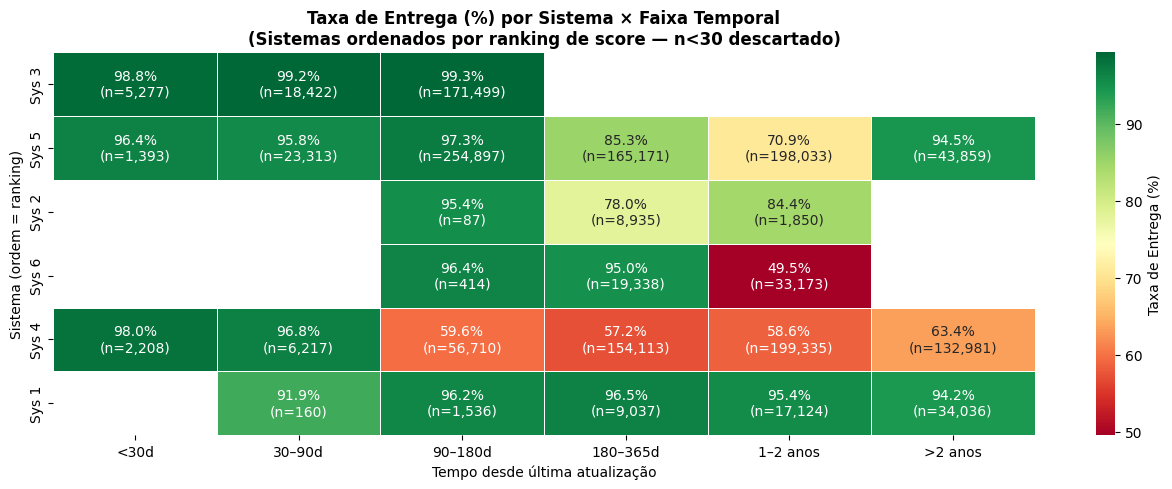

In [15]:
agg_heat = df_tempo.groupby(['sistema_alias', 'faixa_temporal'], observed=False).agg(
    n=('sucesso', 'count'),
    sucessos=('sucesso', 'sum')
).reset_index()
agg_heat['taxa'] = np.where(agg_heat['n'] >= 30,
                            agg_heat['sucessos'] / agg_heat['n'], np.nan)

pivot   = agg_heat.pivot(index='sistema_alias', columns='faixa_temporal', values='taxa') * 100
pivot_n = agg_heat.pivot(index='sistema_alias', columns='faixa_temporal', values='n')

# Reordenar linhas pelo ranking de score
ordem = agg_sistema.reset_index(drop=True).sort_values('score_sistema', ascending=False)['sistema_alias'].tolist()
pivot   = pivot.reindex([s for s in ordem if s in pivot.index])
pivot_n = pivot_n.reindex([s for s in ordem if s in pivot_n.index])

annot = pivot.copy().astype(object)
for i in pivot.index:
    for j in pivot.columns:
        t = pivot.loc[i, j]
        n = pivot_n.loc[i, j]
        annot.loc[i, j] = f'{t:.1f}%\n(n={int(n):,})' if pd.notna(t) and pd.notna(n) else 'n<30'

fig, ax = plt.subplots(figsize=(13, 5))
vmin = pivot.stack().min() if not pivot.stack().empty else 0
vmax = pivot.stack().max() if not pivot.stack().empty else 1
sns.heatmap(pivot, annot=annot, fmt='', cmap='RdYlGn',
            vmin=vmin, vmax=vmax, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Taxa de Entrega (%)'})
ax.set_title('Taxa de Entrega (%) por Sistema × Faixa Temporal\n'
             '(Sistemas ordenados por ranking de score — n<30 descartado)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Tempo desde última atualização')
ax.set_ylabel('Sistema (ordem = ranking)')
plt.tight_layout()
plt.show()

## 8. Exportar Artefatos para Notebook 03

In [16]:
import json, os
os.makedirs('../data', exist_ok=True)

# Salvar ranking de sistemas
agg_sistema.reset_index(drop=True).to_csv('../data/ranking_sistemas.csv', index=False)

# Salvar parâmetros do modelo de decaimento
with open('../data/decay_params.json', 'w') as f:
    json.dump({
        'P0': float(P0_hat),
        'lambda': float(lambda_hat),
        'meia_vida_dias': float(meia_vida),
        'prazo_validade_dias': float(prazo_80pct)
    }, f, indent=2)

# Salvar mapa de aliases para uso nos demais notebooks
with open('../data/alias_map.json', 'w') as f:
    json.dump(alias_map, f, indent=2)

print('Artefatos exportados:')
print('  data/ranking_sistemas.csv')
print('  data/decay_params.json')
print('  data/alias_map.json')
print(f'\nResumo: λ={lambda_hat:.6f}, t½={meia_vida:.0f}d, prazo_validade={prazo_80pct:.0f}d')
print('\nRanking final:')
for _, row in agg_sistema.reset_index(drop=True).sort_values('score_sistema', ascending=False).iterrows():
    print(f"  {row['sistema_alias']}: taxa_bruta={row['taxa_bruta']*100:.2f}%  score={row['score_sistema']*100:.2f}%")

Artefatos exportados:
  data/ranking_sistemas.csv
  data/decay_params.json
  data/alias_map.json

Resumo: λ=0.000462, t½=1502d, prazo_validade=483d

Ranking final:
  Sys 3: taxa_bruta=99.29%  score=99.26%
  Sys 5: taxa_bruta=86.59%  score=86.50%
  Sys 2: taxa_bruta=79.21%  score=78.44%
  Sys 6: taxa_bruta=66.53%  score=66.12%
  Sys 4: taxa_bruta=50.99%  score=50.91%
  Sys 1: taxa_bruta=47.93%  score=47.88%


## 9. Conclusões

### Parte 1.1 — Qualidade por Sistema

1. **Viés de seleção**: Sistemas com alto volume histórico não são necessariamente os melhores — a análise bruta seria enganosa.
2. **Correção via Wilson LB**: Score conservador que penaliza sistemas com pouca evidência e favorece alta taxa *e* alto volume.
3. **Ranking**: Separou performance genuína de preferência histórica do motor de disparos.

### Parte 1.2 — Decaimento Temporal

4. **Decaimento confirmado**: Taxa de entrega cai sistematicamente conforme o registro envelhece.
5. **Modelo**: $P(t) = P_0 \cdot e^{-\lambda t}$ com meia-vida estimada e prazo de validade calculados.
6. **Heatmap**: Permite identificar sistemas mais resilientes ao envelhecimento — insumo direto para o algoritmo de score.

---
**Próximo passo**: Notebook 03 — Ranking Final e Algoritmo de Escolha dos Melhores Telefones.